In [ ]:
Context: https://github.com/JulenErcibengoaTekniker/IberFire/blob/main/notebooks/1.0-DatacubeVisualization/1.2-Visualisation-of-IberFire.ipynb

In [51]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import dask

ds = xr.open_dataset("IberFire.nc", chunks="auto")
print(ds)

<xarray.Dataset> Size: 731GB
Dimensions:                                        (y: 920, x: 1188, time: 6241)
Coordinates:
  * y                                              (y) float64 7kB 2.492e+06 ...
  * x                                              (x) float64 10kB 2.675e+06...
  * time                                           (time) datetime64[ns] 50kB ...
Data variables: (12/261)
    x_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    y_index                                        (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_spain                                       (y, x) uint16 2MB dask.array<chunksize=(920, 1188), meta=np.ndarray>
    is_fire                                        (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=np.ndarray>
    is_near_fire                                   (time, y, x) uint8 7GB dask.array<chunksize=(1562, 230, 298), meta=

In [52]:
ds["is_spain"].sum()

<xarray.DataArray 'is_spain' ()> Size: 8B
dask.array<sum-aggregate, shape=(), dtype=uint64, chunksize=(), chunktype=numpy.ndarray>
Attributes:
    description:   Binary mask indicating the Spanish region: 1 for Spanish r...
    valid_values:  {0, 1}
    data_type:     uint8

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.colors import ListedColormap, BoundaryNorm
import ipywidgets as widgets
from datetime import datetime

cmap = ListedColormap([
    "#2c7bb6",  # Sea
    "#d9d9d9",  # Land
    "#66bd63",  # Spain
    "#d7191c",  # Fire
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

legend_labels = ["Sea", "Land", "Spain", "Fire"]
legend_handles = [
    plt.Line2D([0], [0], marker="s", linestyle="",
               markerfacecolor=cmap(i), markersize=10)
    for i in range(4)
]

out = widgets.Output()

def plot_fire_at_date(date):
    with out:
        out.clear_output(wait=True)

        ds_t = ds.sel(time=np.datetime64(date))

        category = xr.zeros_like(ds_t["is_spain"], dtype=np.uint8)

        category = xr.where(ds_t["is_sea"] == 1, 0, category)
        category = xr.where(
            (ds_t["is_sea"] == 0) & (ds_t["is_spain"] == 0),
            1,
            category,
        )
        category = xr.where(
            (ds_t["is_spain"] == 1) & (ds_t["is_fire"] == 0),
            2,
            category,
        )
        category = xr.where(ds_t["is_fire"] == 1, 3, category)

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(category, cmap=cmap, norm=norm)
        ax.set_title(f"Fire occurrence – {date}")
        ax.axis("off")

        ax.legend(
            legend_handles,
            legend_labels,
            loc="lower left",
            frameon=True
        )

        plt.show()


In [54]:
dates = ds.time.values.astype("datetime64[D]").astype(str)

slider = widgets.SelectionSlider(
    options=dates,
    value=dates[0],
    description="Date",
    layout=widgets.Layout(width="800px"),
    continuous_update=False
)

datepicker = widgets.DatePicker(
    description="Select date",
    value=datetime.strptime(dates[0], "%Y-%m-%d")
)


In [55]:
def on_slider_change(change):
    datepicker.value = datetime.strptime(change["new"], "%Y-%m-%d")
    plot_fire_at_date(change["new"])

def on_datepicker_change(change):
    date_str = change["new"].strftime("%Y-%m-%d")
    slider.value = date_str

slider.observe(on_slider_change, names="value")
datepicker.observe(on_datepicker_change, names="value")


In [56]:
plot_fire_at_date(dates[0])

widgets.VBox([
    slider,
    datepicker,
    out
])

In [139]:
import xarray as xr
import numpy as np
import pandas as pd

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))
days_before = [1, 2, 3, 4, 5]

fire = ds_2022["is_fire"]
fire_start = (fire == 1) & (fire.shift(time=1) == 0)

vars_to_analyze = [
    "LAI", "NDVI", "LST",
    "SWI_001", "SWI_005", "SWI_010", "SWI_020",
    "t2m_mean", "RH_mean", "surface_pressure_mean", 
    "total_precipitation_mean", "wind_speed_mean", "wind_direction_mean"
]

# ============================================================
# STEP 1: Load fire_start mask to memory ONCE
# ============================================================
print("Loading fire_start mask to memory...")
fire_start_vals = fire_start.values  # shape: (time, y, x)

# ============================================================
# STEP 2: Precompute ALL shifted masks ONCE (not per variable!)
# ============================================================
print("Precomputing shifted masks for all days...")
fire_start_shifted = {}
for d in days_before:
    # np.roll shifts along axis, but wraps around - we need to handle edges
    shifted = np.roll(fire_start_vals, d, axis=0)
    shifted[:d, :, :] = False  # First d timesteps have no valid "before" data
    fire_start_shifted[d] = shifted
    print(f"  Prepared mask for {d} day(s) before")

# ============================================================
# STEP 3: Load ALL variables to memory ONCE
# ============================================================
print("Loading all variables to memory...")
data_vars = {}
for var in vars_to_analyze:
    data_vars[var] = ds_2022[var].values
    print(f"  Loaded {var}: {data_vars[var].shape}")

# ============================================================
# STEP 4: Process with pure NumPy (no xarray overhead!)
# ============================================================
print("\nExtracting values...")
results = {}

for var in vars_to_analyze:
    var_data = data_vars[var]
    results[var] = {}
   
    for d in days_before:
        mask = fire_start_shifted[d]
       
        # Direct boolean indexing - much faster than .where()
        values = var_data[mask]
        values = values[~np.isnan(values)]
       
        results[var][d] = values.tolist()
   
    print(f"  {var}: {sum(len(results[var][d]) for d in days_before)} total values")

print("Done!")


Loading fire_start mask to memory...
Precomputing shifted masks for all days...
  Prepared mask for 1 day(s) before
  Prepared mask for 2 day(s) before
  Prepared mask for 3 day(s) before
  Prepared mask for 4 day(s) before
  Prepared mask for 5 day(s) before
Loading all variables to memory...
  Loaded LAI: (370, 920, 1188)
  Loaded NDVI: (370, 920, 1188)
  Loaded LST: (370, 920, 1188)
  Loaded SWI_001: (370, 920, 1188)
  Loaded SWI_005: (370, 920, 1188)
  Loaded SWI_010: (370, 920, 1188)
  Loaded SWI_020: (370, 920, 1188)
  Loaded t2m_mean: (370, 920, 1188)
  Loaded RH_mean: (370, 920, 1188)
  Loaded surface_pressure_mean: (370, 920, 1188)
  Loaded total_precipitation_mean: (370, 920, 1188)
  Loaded wind_speed_mean: (370, 920, 1188)
  Loaded wind_direction_mean: (370, 920, 1188)

Extracting values...
  LAI: 37670 total values
  NDVI: 37781 total values
  LST: 37755 total values
  SWI_001: 37630 total values
  SWI_005: 37630 total values
  SWI_010: 37630 total values
  SWI_020: 37630 t

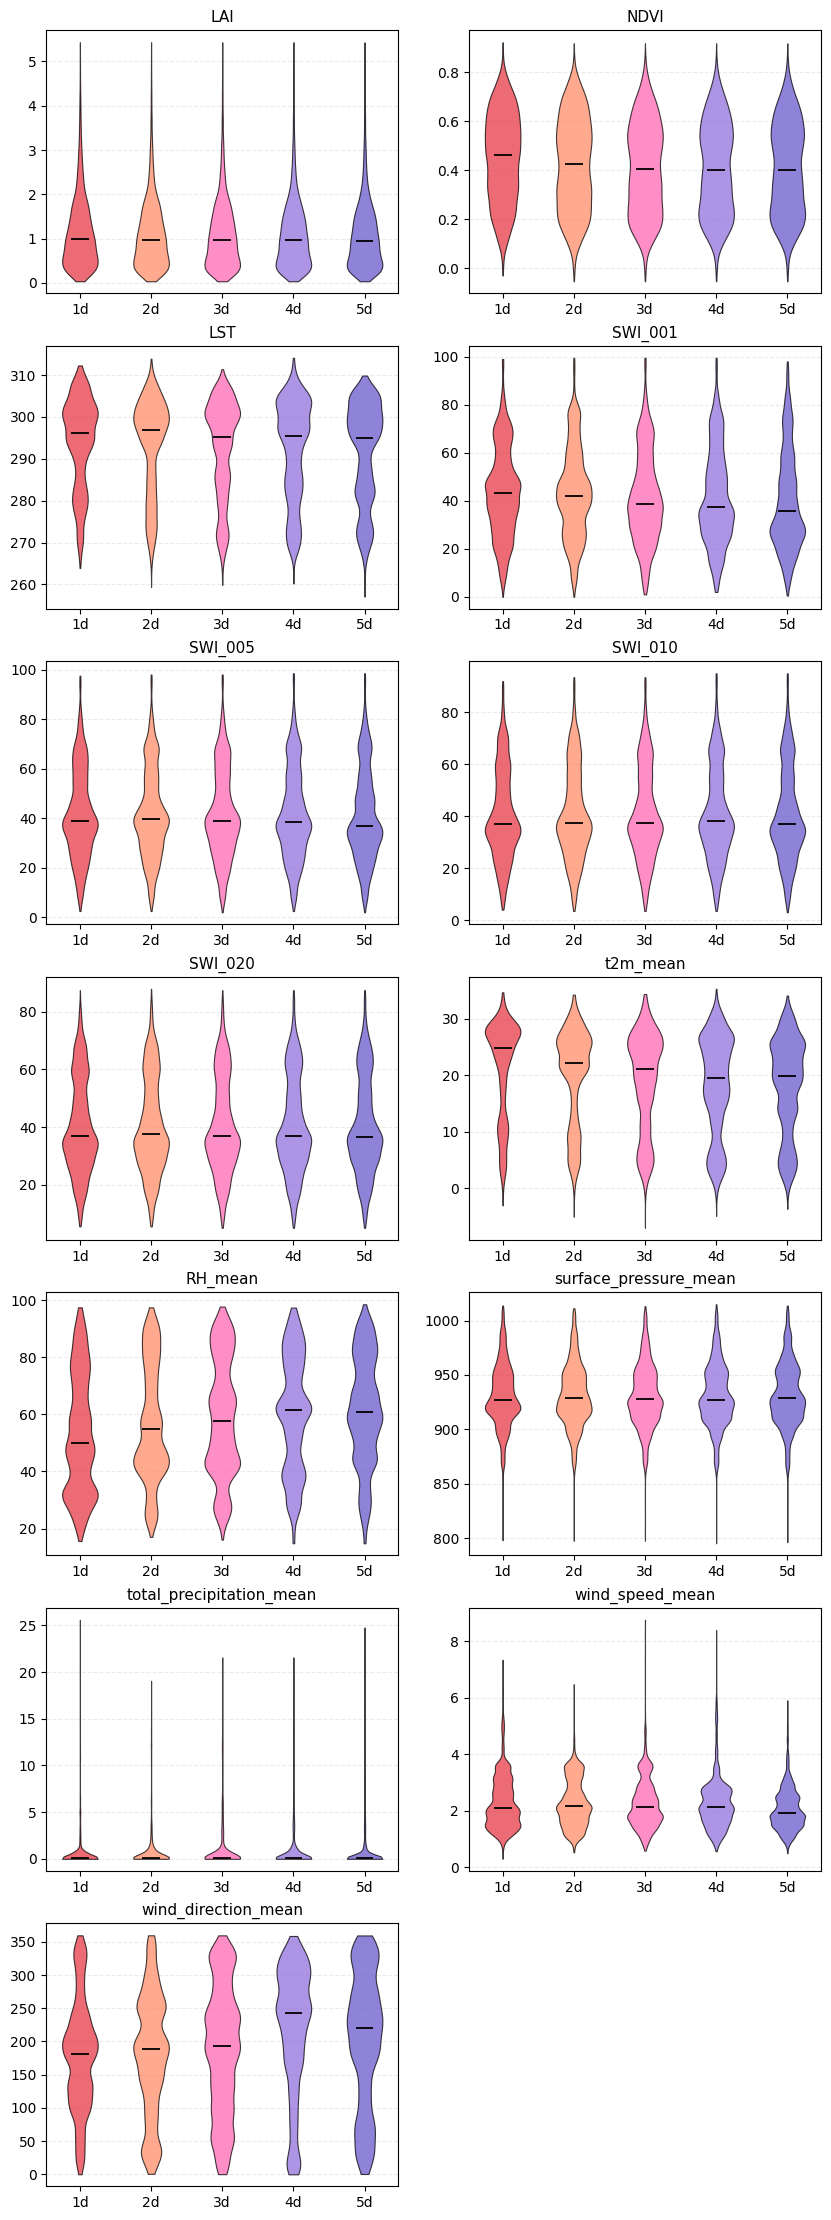

In [140]:
import matplotlib.pyplot as plt
import math

n_vars = len(vars_to_analyze)
n_cols = 2
n_rows = math.ceil(n_vars / n_cols)

day_colors = {
    5: "#6A5ACD",  # purple
    4: "#9370DB",  # lavender
    3: "#FF69B4",  # pink
    2: "#FF8C69",  # coral
    1: "#E63946",  # red
}

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    squeeze=False
)

for i, var in enumerate(vars_to_analyze):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]

    data = [results[var][d] for d in days_before]

    parts = ax.violinplot(
        data,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # Color each violin
    for body, d in zip(parts["bodies"], days_before):
        body.set_facecolor(day_colors[d])
        body.set_edgecolor("black")
        body.set_alpha(0.75)
        body.set_linewidth(0.8)

    # Median styling
    parts["cmedians"].set_color("black")
    parts["cmedians"].set_linewidth(1.3)

    # Axis styling
    ax.set_title(var, fontsize=11, pad=6)
    ax.set_xticks(range(1, len(days_before) + 1))
    ax.set_xticklabels([f"{d}d" for d in days_before])
    ax.grid(axis="y", alpha=0.25, linestyle="--")
    ax.set_axisbelow(True)

for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j // n_cols, j % n_cols])

In [119]:
code_labels = {
    0: "Nodata",
    1: "Andalucía",
    2: "Aragón",
    3: "Principado de Asturias",
    4: "Islas Baleares",
    5: "Canarias",
    6: "Cantabria",
    7: "Castilla y León",
    8: "Castilla - La Mancha",
    9: "Cataluña",
    10: "Comunidad Valenciana",
    11: "Extremadura",
    12: "Galicia",
    13: "Comunidad de Madrid",
    14: "Región de Murcia",
    15: "Comunidad Foral de Navarra",
    16: "País Vasco",
    17: "La Rioja",
    18: "Ceuta",
    19: "Melilla"
}

In [134]:
import numpy as np
import pandas as pd

ds_2022 = ds.sel(time=slice("2021-12-27", "2022-12-31"))

fire = ds_2022["is_fire"]

fire_start = (fire == 1) & (fire.shift(time=1) == 0)
fire_end   = (fire == 1) & (fire.shift(time=-1) == 0)

# Load all arrays to memory ONCE (avoids repeated xarray overhead)
print("Loading data to memory...")
fire_start_vals = fire_start.values  
fire_end_vals = fire_end.values
time_vals = ds_2022["time"].values

# Static variables (no time dimension)
aspect_vals = {i: ds_2022[f"aspect_{i}"].values for i in range(1, 9)}
elevation_vals = ds_2022["elevation_mean"].values
slope_vals = ds_2022["slope_mean"].values
roughness_vals = ds_2022["roughness_mean"].values

# Find fire pixels
has_fire_ever = fire_start_vals.any(axis=0)
fire_pixels = np.argwhere(has_fire_ever)

print(f"Processing {len(fire_pixels)} fire pixels...")

Loading data to memory...
Processing 7272 fire pixels...


In [135]:
records = []
for iy, ix in fire_pixels:
    starts = np.where(fire_start_vals[:, iy, ix])[0]
    ends = np.where(fire_end_vals[:, iy, ix])[0]
    
    for s, e in zip(starts, ends):
        records.append({
            "duration": e - s + 1,
            "y": iy,
            "x": ix,
            **{f"aspect_{i}": aspect_vals[i][iy, ix] for i in range(1, 9)},
            "elevation_mean": elevation_vals[iy, ix],
            "slope_mean": slope_vals[iy, ix],
            "roughness_mean": roughness_vals[iy, ix],
        })

In [136]:
df_fires = pd.DataFrame(records)

In [137]:
df_fires = pd.DataFrame(records)
aspect_cols = [f"aspect_{i}" for i in range(1, 9)]
df_fires["dominant_aspect"] = df_fires[aspect_cols].idxmax(axis=1)
df_fires["dominant_aspect"] = df_fires["dominant_aspect"].str.extract(r"(\d)").astype(int)

aspect_stats = (
    df_fires
    .groupby("dominant_aspect")["duration"]
    .agg(["mean", "count"])
    .reindex(range(1, 9))
)

print(aspect_stats)

                     mean  count
dominant_aspect                 
1                3.409501   1663
2                2.775610    410
3                2.789227    427
4                3.461099   1401
5                3.493865   1630
6                2.946835    395
7                2.686649    367
8                3.484634   1269


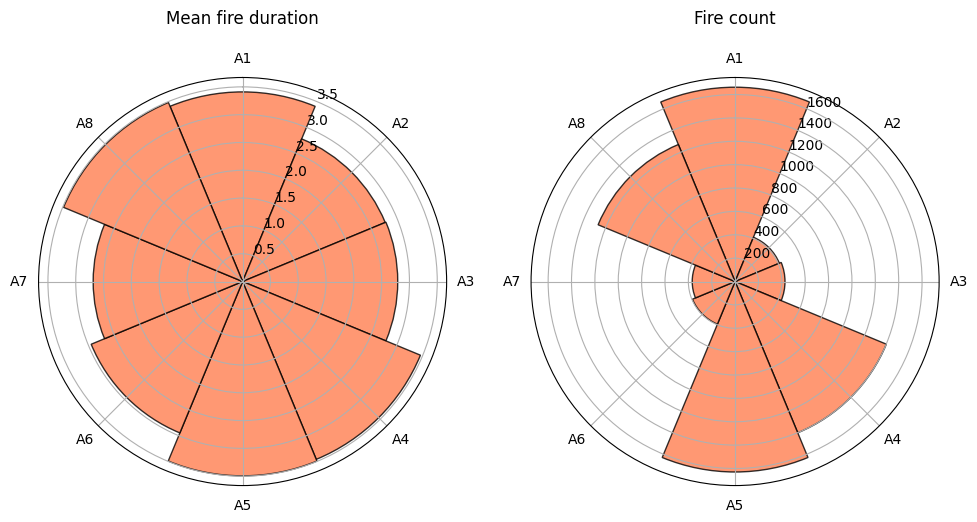

In [145]:
n_cols = 2
n_rows = 1

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5 * n_cols, 5 * n_rows),
    squeeze=False,
    subplot_kw={'projection': 'polar'}  # ← Makes all subplots polar!
)

titles = {"mean": "Mean fire duration", "count": "Fire count"}

for i, kind in enumerate(["mean", "count"]):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]  # Now this IS a polar axis
   
    # NO new figure creation here!
   
    bars = ax.bar(
        angles,
        aspect_stats[kind],
        width=width,
        bottom=0,
        color="coral",
        edgecolor="black",
        alpha=0.8
    )
   
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels([f"A{i}" for i in range(1, 9)])
   
    ax.set_title(titles[kind], pad=20)

plt.tight_layout()
plt.show()

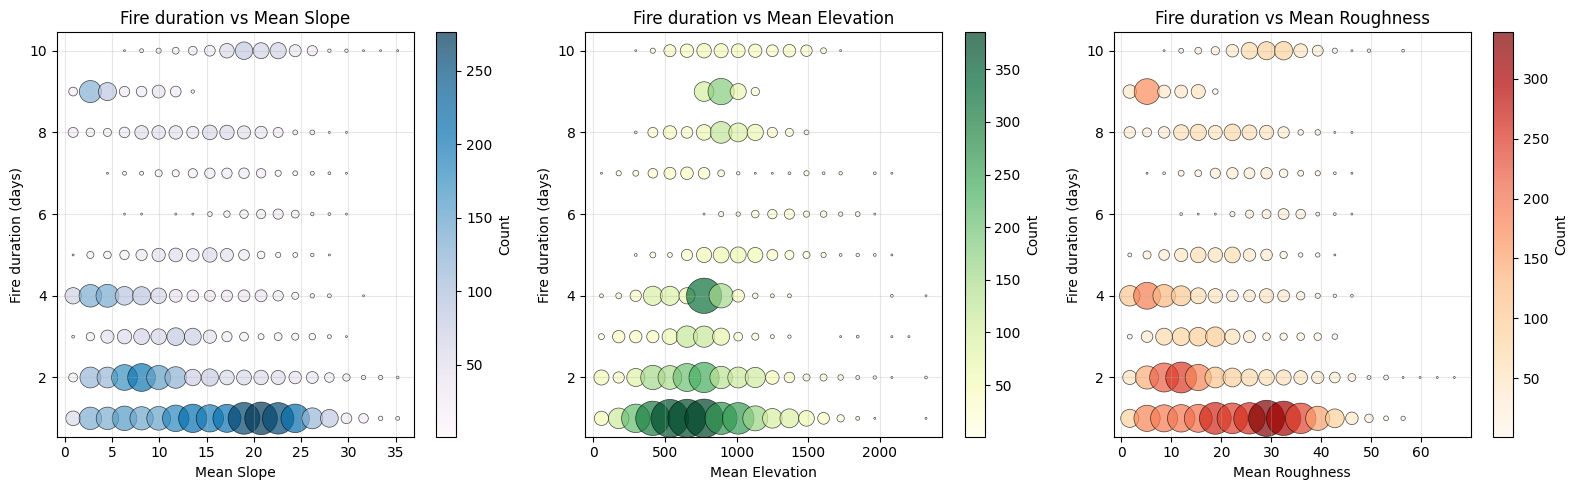

In [162]:
df_filtered = df_fires[df_fires["duration"] >= 0]

terrain_vars = [
    ("slope_mean", "Mean Slope", "PuBu"),
    ("elevation_mean", "Mean Elevation", "YlGn"),
    ("roughness_mean", "Mean Roughness", "OrRd")
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (var, label, color) in zip(axes, terrain_vars):
    # Bin the x variable and count occurrences
    df_temp = df_filtered[[var, "duration"]].dropna()
   
    # Create bins for the terrain variable
    df_temp["var_binned"] = pd.cut(df_temp[var], bins=20, labels=False)
    bin_edges = pd.cut(df_temp[var], bins=20, retbins=True)[1]
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
   
    # Group and count
    grouped = df_temp.groupby(["var_binned", "duration"]).size().reset_index(name="count")
    grouped["var_center"] = grouped["var_binned"].map(lambda i: bin_centers[int(i)] if pd.notna(i) else np.nan)
   
    # Plot bubbles
    scatter = ax.scatter(
        grouped["var_center"],
        grouped["duration"],
        s=grouped["count"] * 2,  # Scale factor for visibility
        c=grouped["count"],
        cmap=color,
        alpha=0.7,
        edgecolors="black",
        linewidths=0.5
    )
   
    ax.set_xlabel(label)
    ax.set_ylabel("Fire duration (days)")
    ax.set_title(f"Fire duration vs {label}")
    ax.grid(alpha=0.3)
   
    cb = plt.colorbar(scatter, ax=ax)
    cb.set_label("Count")

plt.tight_layout()
plt.show()

In [163]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import label
import seaborn as sns

# ============================================================
# STEP 1: Select 2022 data
# ============================================================
ds_2022 = ds.sel(time=slice("2022-01-01", "2022-12-31"))

print("Loading data to memory (this may take a moment)...")

# ============================================================
# STEP 2: Extrapolate Population Density to 2022
# ============================================================
print("\nExtrapolating population density to 2022...")

# Available years
pop_years = list(range(2008, 2021))  # 2008-2020

# Load all population density layers
pop_data = {}
for year in pop_years:
    pop_data[year] = ds_2022[f"popdens_{year}"].values  # Shape: (y, x)
    print(f"  Loaded popdens_{year}")

# Stack into 3D array: (year, y, x)
pop_stack = np.stack([pop_data[y] for y in pop_years], axis=0)

# Perform pixel-wise linear regression to extrapolate
print("\nPerforming pixel-wise linear regression...")
ny, nx = pop_stack.shape[1], pop_stack.shape[2]
years_array = np.array(pop_years)
target_year = 2022

# Vectorized approach for speed
# Reshape to (n_years, n_pixels)
pop_flat = pop_stack.reshape(len(pop_years), -1)

# Calculate regression for all pixels at once
# Using the formula: slope = Σ((x-x̄)(y-ȳ)) / Σ((x-x̄)²)
x = years_array
x_mean = x.mean()
x_centered = x - x_mean

# For each pixel
y_mean = np.nanmean(pop_flat, axis=0)
y_centered = pop_flat - y_mean

numerator = np.nansum(x_centered[:, np.newaxis] * y_centered, axis=0)
denominator = np.sum(x_centered ** 2)

slopes = numerator / denominator
intercepts = y_mean - slopes * x_mean

# Extrapolate to 2022
popdens_2022_flat = slopes * target_year + intercepts
popdens_2022 = popdens_2022_flat.reshape(ny, nx)

# Ensure no negative population densities
popdens_2022 = np.maximum(popdens_2022, 0)

print(f"  Population density 2022 extrapolated: shape {popdens_2022.shape}")
print(f"  Range: {np.nanmin(popdens_2022):.1f} - {np.nanmax(popdens_2022):.1f}")

# ============================================================
# STEP 3: Load infrastructure distance variables
# ============================================================
print("\nLoading infrastructure variables...")

infrastructure_vars = {
    "dist_roads_mean": ds_2022["dist_to_roads_mean"].values,
    "dist_roads_std": ds_2022["dist_to_roads_stdev"].values,
    "dist_water_mean": ds_2022["dist_to_waterways_mean"].values,
    "dist_water_std": ds_2022["dist_to_waterways_stdev"].values,
    "dist_rail_mean": ds_2022["dist_to_railways_mean"].values,
    "dist_rail_std": ds_2022["dist_to_railways_stdev"].values,
}

for name, arr in infrastructure_vars.items():
    print(f"  Loaded {name}: {arr.shape}")

# ============================================================
# STEP 4: Process fire events (optimized)
# ============================================================
print("\nProcessing fire events...")

fire = ds_2022["is_fire"]
fire_vals = fire.values
fire_vals = np.nan_to_num(fire_vals, nan=0)

# Find fire starts
fire_start = (fire_vals == 1) & (np.roll(fire_vals, 1, axis=0) == 0)
fire_start[0, :, :] = fire_vals[0, :, :] == 1  # Handle first timestep

# Find pixels with fires
has_fire = fire_vals.any(axis=0)
fire_pixels = np.argwhere(has_fire)
print(f"  Found {len(fire_pixels)} pixels with fire activity")

# Extract fire events with all attributes
records = []

for iy, ix in fire_pixels:
    ts = fire_vals[:, iy, ix]
   
    # Label connected fire segments
    labels, n_fires = label(ts)
   
    for fire_id in range(1, n_fires + 1):
        fire_indices = np.where(labels == fire_id)[0]
        duration = len(fire_indices)
       
        records.append({
            "y": iy,
            "x": ix,
            "duration": duration,
            "popdens_2022": popdens_2022[iy, ix],
            "dist_roads_mean": infrastructure_vars["dist_roads_mean"][iy, ix],
            "dist_roads_std": infrastructure_vars["dist_roads_std"][iy, ix],
            "dist_water_mean": infrastructure_vars["dist_water_mean"][iy, ix],
            "dist_water_std": infrastructure_vars["dist_water_std"][iy, ix],
            "dist_rail_mean": infrastructure_vars["dist_rail_mean"][iy, ix],
            "dist_rail_std": infrastructure_vars["dist_rail_std"][iy, ix],
        })

df_fires = pd.DataFrame(records)
print(f"  Extracted {len(df_fires)} fire events")

# Filter valid data
df_fires = df_fires[df_fires["duration"] > 0]
df_fires = df_fires.dropna()
print(f"  After filtering: {len(df_fires)} events")

print("\nData preparation complete!")
print(df_fires.describe())

Loading data to memory (this may take a moment)...

Extrapolating population density to 2022...
  Loaded popdens_2008
  Loaded popdens_2009
  Loaded popdens_2010
  Loaded popdens_2011
  Loaded popdens_2012
  Loaded popdens_2013
  Loaded popdens_2014
  Loaded popdens_2015
  Loaded popdens_2016
  Loaded popdens_2017
  Loaded popdens_2018
  Loaded popdens_2019
  Loaded popdens_2020

Performing pixel-wise linear regression...
  Population density 2022 extrapolated: shape (920, 1188)
  Range: 0.0 - 30725.7

Loading infrastructure variables...
  Loaded dist_roads_mean: (920, 1188)
  Loaded dist_roads_std: (920, 1188)
  Loaded dist_water_mean: (920, 1188)
  Loaded dist_water_std: (920, 1188)
  Loaded dist_rail_mean: (920, 1188)
  Loaded dist_rail_std: (920, 1188)

Processing fire events...
  Found 7212 pixels with fire activity
  Extracted 7490 fire events
  After filtering: 7490 events

Data preparation complete!
                y            x     duration  popdens_2022  dist_roads_mean  \
c

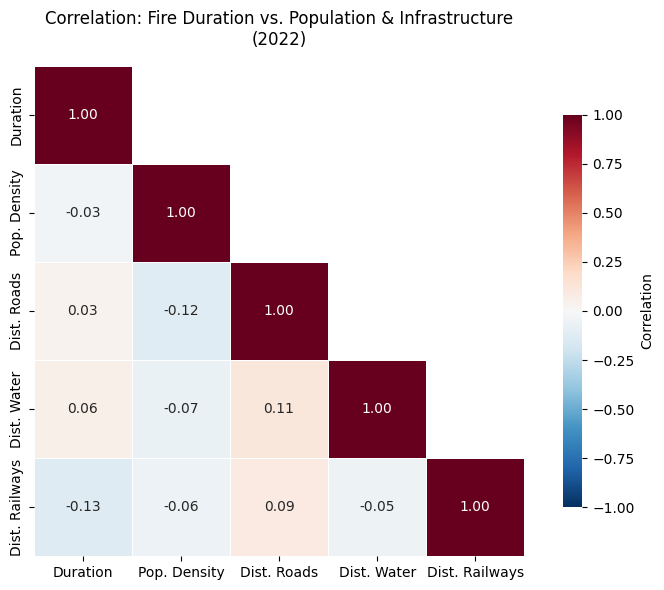

In [164]:
# ============================================================
# VISUALIZATION 1: Correlation Heatmap
# ============================================================
plt.close('all')

corr_cols = [
    "duration", "popdens_2022",
    "dist_roads_mean", "dist_water_mean", "dist_rail_mean"
]

corr_matrix = df_fires[corr_cols].corr()

# Rename for prettier labels
rename_map = {
    "duration": "Duration",
    "popdens_2022": "Pop. Density",
    "dist_roads_mean": "Dist. Roads",
    "dist_water_mean": "Dist. Water",
    "dist_rail_mean": "Dist. Railways"
}
corr_matrix = corr_matrix.rename(index=rename_map, columns=rename_map)

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlation"},
    ax=ax
)

ax.set_title("Correlation: Fire Duration vs. Population & Infrastructure\n(2022)",
             fontsize=12, pad=15)

plt.tight_layout()
plt.show()

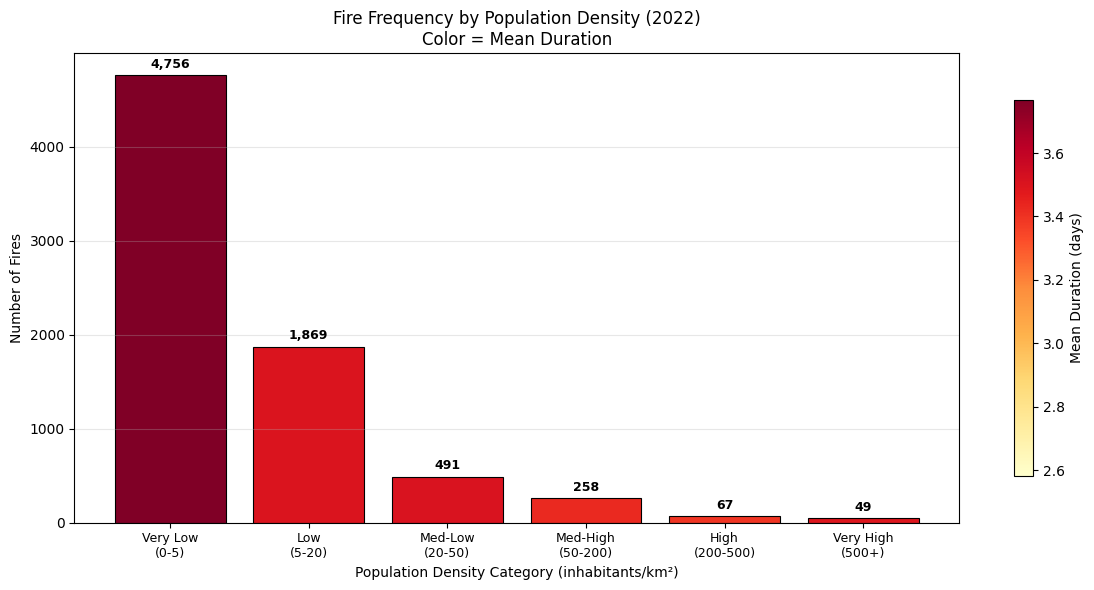


Fire count by population density bin:
           pop_bin  fire_count  mean_duration
   Very Low\n(0-5)        4756       3.767031
       Low\n(5-20)        1869       2.939005
  Med-Low\n(20-50)         491       2.945010
Med-High\n(50-200)         258       2.678295
   High\n(200-500)          67       2.582090
 Very High\n(500+)          49       2.897959


In [177]:
# ============================================================
# VISUALIZATION 2: Binned Bar Chart (FIXED)
# ============================================================
plt.close('all')

# Option A: Custom bins based on your data distribution (RECOMMENDED for skewed data)
# Since mean=20 but max=3700, use log-like spacing
custom_bins = [0, 5, 20, 50, 200, 500, df_fires["popdens_2022"].max() + 1]
custom_labels = ["Very Low\n(0-5)", "Low\n(5-20)", "Med-Low\n(20-50)",
                 "Med-High\n(50-200)", "High\n(200-500)", "Very High\n(500+)"]

df_fires["pop_bin"] = pd.cut(
    df_fires["popdens_2022"],
    bins=custom_bins,
    labels=custom_labels,
    include_lowest=True
)

# Aggregate by bin
pop_stats = df_fires.groupby("pop_bin", observed=True).agg(
    fire_count=("duration", "count"),
    mean_duration=("duration", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    range(len(pop_stats)),
    pop_stats["fire_count"],
    color=plt.cm.YlOrRd(pop_stats["mean_duration"] / pop_stats["mean_duration"].max()),
    edgecolor="black",
    linewidth=0.8
)

ax.set_xticks(range(len(pop_stats)))
ax.set_xticklabels(pop_stats["pop_bin"], fontsize=9)
ax.set_xlabel("Population Density Category (inhabitants/km²)")
ax.set_ylabel("Number of Fires")
ax.set_title("Fire Frequency by Population Density (2022)\nColor = Mean Duration", fontsize=12)
ax.grid(axis="y", alpha=0.3)

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(
        vmin=pop_stats["mean_duration"].min(),
        vmax=pop_stats["mean_duration"].max()
    )
)
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
cbar.set_label("Mean Duration (days)")

# Add count labels on bars
for bar, count in zip(bars, pop_stats["fire_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(pop_stats["fire_count"]) * 0.01,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# Print the distribution
print("\nFire count by population density bin:")
print(pop_stats[["pop_bin", "fire_count", "mean_duration"]].to_string(index=False))

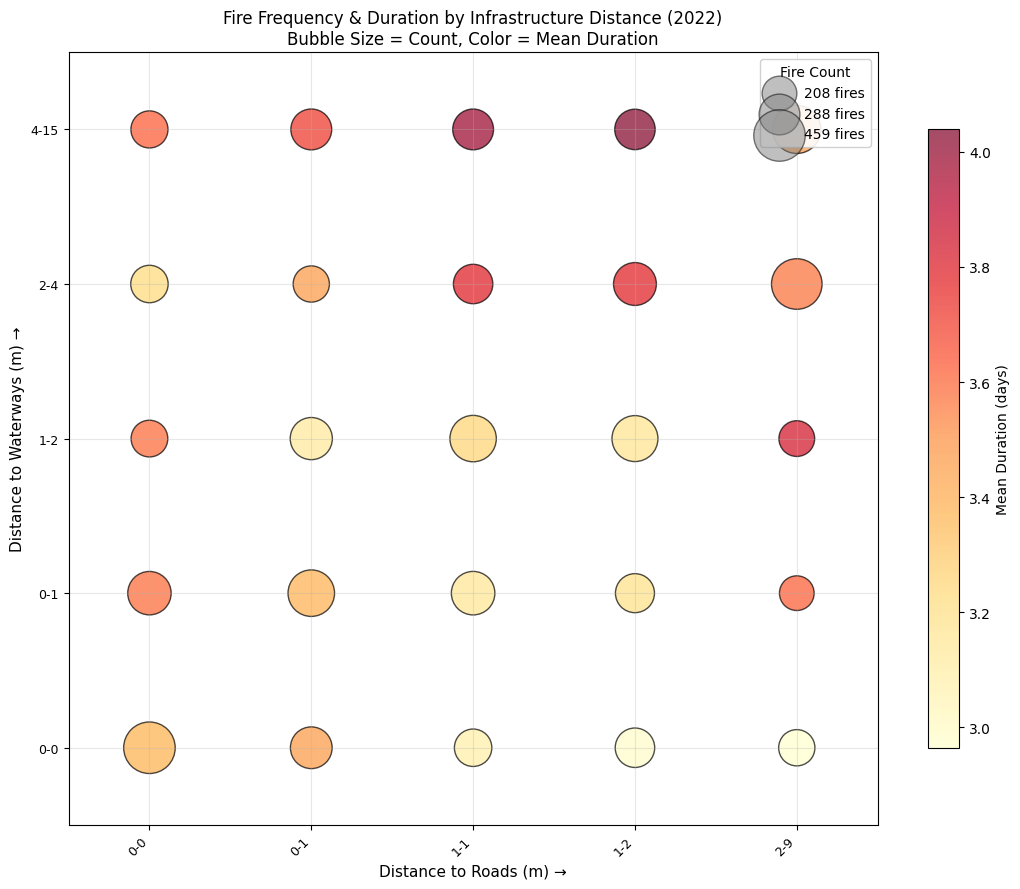

In [178]:
# ============================================================
# VISUALIZATION 3: Bubble Matrix (FIXED with range labels)
# ============================================================
plt.close('all')

n_bins = 5

# Create bins and capture the actual ranges
df_fires["roads_bin"], roads_edges = pd.qcut(
    df_fires["dist_roads_mean"],
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates="drop"
)

df_fires["water_bin"], water_edges = pd.qcut(
    df_fires["dist_water_mean"],
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates="drop"
)

# Create labels with actual ranges
roads_labels = [f"{roads_edges[i]:.0f}-{roads_edges[i+1]:.0f}"
                for i in range(len(roads_edges)-1)]
water_labels = [f"{water_edges[i]:.0f}-{water_edges[i+1]:.0f}"
                for i in range(len(water_edges)-1)]

# Aggregate
bubble_data = df_fires.groupby(["roads_bin", "water_bin"], observed=True).agg(
    count=("duration", "count"),
    mean_duration=("duration", "mean")
).reset_index()

fig, ax = plt.subplots(figsize=(11, 9))

scatter = ax.scatter(
    bubble_data["roads_bin"],
    bubble_data["water_bin"],
    s=bubble_data["count"] * 3,
    c=bubble_data["mean_duration"],
    cmap="YlOrRd",
    alpha=0.7,
    edgecolors="black",
    linewidths=1
)

# Set ticks with actual range labels
ax.set_xticks(range(len(roads_labels)))
ax.set_xticklabels(roads_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(water_labels)))
ax.set_yticklabels(water_labels, fontsize=9)

ax.set_xlabel("Distance to Roads (m) →", fontsize=11)
ax.set_ylabel("Distance to Waterways (m) →", fontsize=11)
ax.set_title("Fire Frequency & Duration by Infrastructure Distance (2022)\n"
             "Bubble Size = Count, Color = Mean Duration", fontsize=12)

ax.set_xlim(-0.5, len(roads_labels) - 0.5)
ax.set_ylim(-0.5, len(water_labels) - 0.5)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label("Mean Duration (days)")

# Legend for bubble size
sizes_for_legend = [
    bubble_data["count"].min(),
    bubble_data["count"].median(),
    bubble_data["count"].max()
]
for size in sizes_for_legend:
    ax.scatter([], [], s=size*3, c="gray", alpha=0.5,
               edgecolors="black", label=f"{int(size)} fires")
ax.legend(title="Fire Count", loc="upper right", framealpha=0.9)

plt.tight_layout()
plt.show()

Duration thresholds: Short ≤2, Medium ≤5, Long ≤9, Very Long >9
Category counts:
duration_cat
Short        4143
Medium       1761
Long         1169
Very Long     417
Name: count, dtype: int64


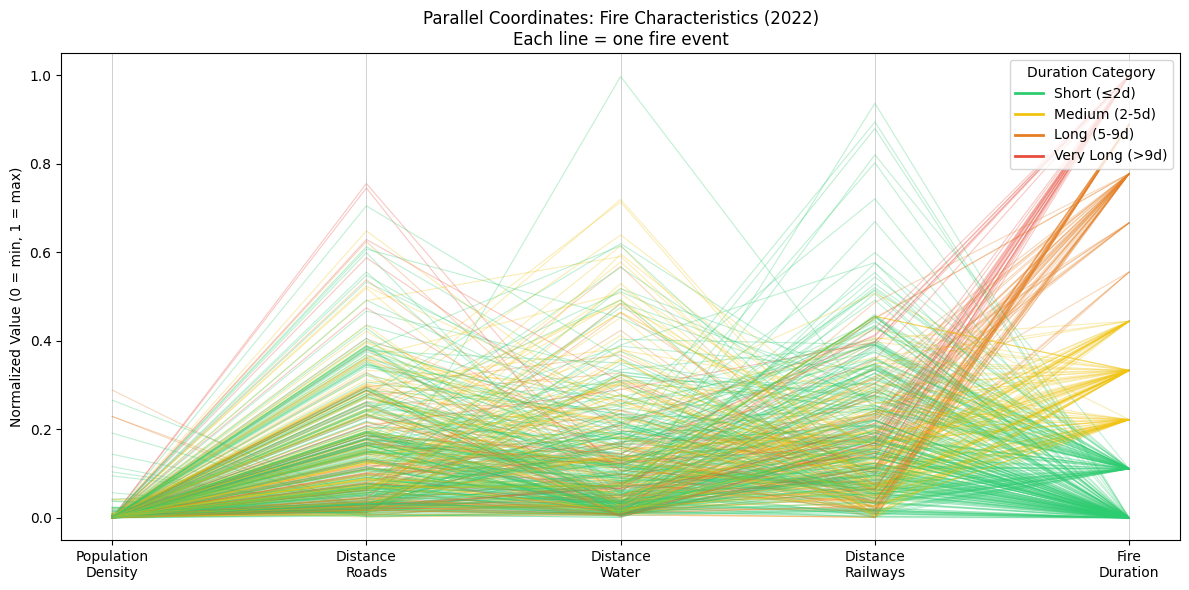

In [180]:

# ============================================================
# VISUALIZATION 4: Parallel Coordinates (FIXED)
# ============================================================
plt.close('all')

# Prepare data - normalize all columns to 0-1 range
parallel_cols = [
    "popdens_2022", "dist_roads_mean", "dist_water_mean",
    "dist_rail_mean", "duration"
]

df_parallel = df_fires[parallel_cols].copy()

# Normalize
for col in parallel_cols:
    min_val = df_parallel[col].min()
    max_val = df_parallel[col].max()
    if max_val > min_val:
        df_parallel[col] = (df_parallel[col] - min_val) / (max_val - min_val)
    else:
        df_parallel[col] = 0.5

# Create duration categories using original (non-normalized) values
# Use custom bins to handle the skewed distribution
duration_values = df_fires["duration"]
duration_median = duration_values.median()
duration_75 = duration_values.quantile(0.75)
duration_90 = duration_values.quantile(0.90)

def categorize_duration(d):
    if d <= duration_median:
        return "Short"
    elif d <= duration_75:
        return "Medium"
    elif d <= duration_90:
        return "Long"
    else:
        return "Very Long"

df_parallel["duration_cat"] = duration_values.apply(categorize_duration)

print(f"Duration thresholds: Short ≤{duration_median:.0f}, "
      f"Medium ≤{duration_75:.0f}, Long ≤{duration_90:.0f}, Very Long >{duration_90:.0f}")
print(f"Category counts:\n{df_parallel['duration_cat'].value_counts()}")

# Sample if too many points (for readability)
if len(df_parallel) > 500:
    df_sample = df_parallel.sample(n=500, random_state=42)
else:
    df_sample = df_parallel

fig, ax = plt.subplots(figsize=(12, 6))

colors = {
    "Short": "#2ecc71",
    "Medium": "#f1c40f",
    "Long": "#e67e22",
    "Very Long": "#e74c3c"
}

x_coords = range(len(parallel_cols))

# Plot lines for each fire event
for _, row in df_sample.iterrows():
    y_coords = [row[col] for col in parallel_cols]
    color = colors.get(row["duration_cat"], "gray")
    ax.plot(x_coords, y_coords, color=color, alpha=0.3, linewidth=0.8)

# Formatting
ax.set_xticks(x_coords)
ax.set_xticklabels([
    "Population\nDensity", "Distance\nRoads", "Distance\nWater",
    "Distance\nRailways", "Fire\nDuration"
], fontsize=10)

ax.set_ylabel("Normalized Value (0 = min, 1 = max)")
ax.set_title("Parallel Coordinates: Fire Characteristics (2022)\n"
             "Each line = one fire event", fontsize=12)

# Add vertical lines at each axis
for x in x_coords:
    ax.axvline(x=x, color="gray", linewidth=0.5, alpha=0.5)

# Legend with thresholds
legend_labels = [
    f"Short (≤{duration_median:.0f}d)",
    f"Medium ({duration_median:.0f}-{duration_75:.0f}d)",
    f"Long ({duration_75:.0f}-{duration_90:.0f}d)",
    f"Very Long (>{duration_90:.0f}d)"
]
legend_handles = [plt.Line2D([0], [0], color=colors[cat], linewidth=2, label=lbl)
                  for cat, lbl in zip(["Short", "Medium", "Long", "Very Long"], legend_labels)]
ax.legend(handles=legend_handles, title="Duration Category", loc="upper right")

ax.set_xlim(-0.2, len(parallel_cols) - 0.8)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

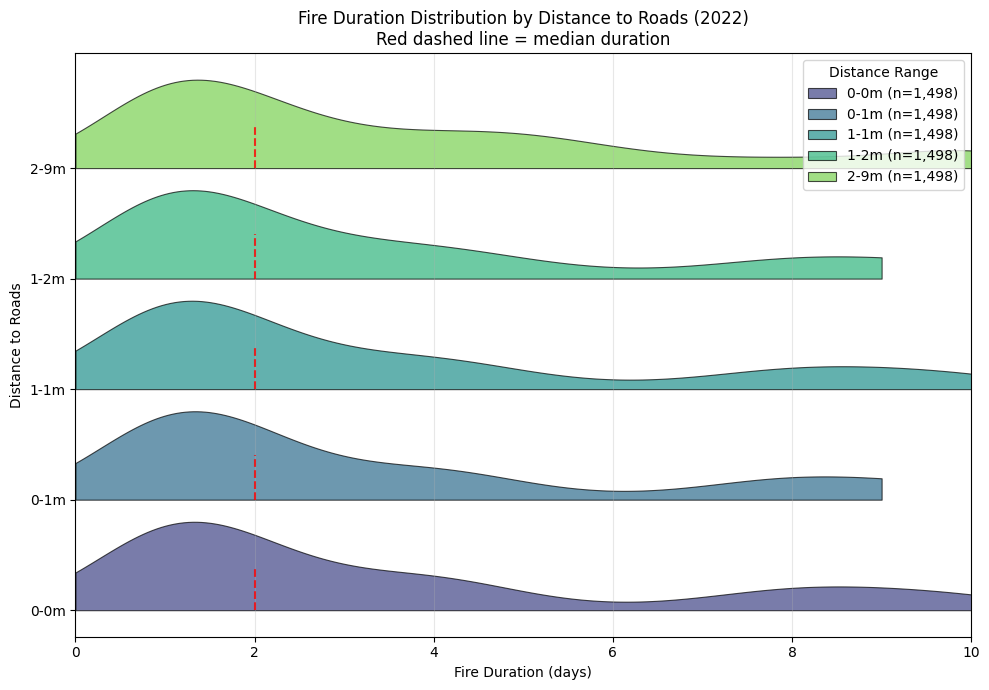

In [181]:
# ============================================================
# VISUALIZATION 5: Ridgeline Plot (FIXED with range labels)
# ============================================================
plt.close('all')

from scipy.stats import gaussian_kde

# Create distance bins and get edges
df_fires["roads_cat"], roads_edges = pd.qcut(
    df_fires["dist_roads_mean"],
    q=5,
    labels=False,
    retbins=True,
    duplicates="drop"
)

# Create labels with ranges
n_cats = len(roads_edges) - 1
categories = [f"{roads_edges[i]:.0f}-{roads_edges[i+1]:.0f}m" for i in range(n_cats)]
df_fires["roads_cat_label"] = df_fires["roads_cat"].map(
    {i: categories[i] for i in range(n_cats)}
)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, n_cats))

fig, ax = plt.subplots(figsize=(10, 7))

for i, (cat, color) in enumerate(zip(categories, colors)):
    subset = df_fires[df_fires["roads_cat_label"] == cat]["duration"]
   
    if len(subset) > 10:
        try:
            kde = gaussian_kde(subset, bw_method=0.3)
            x_range = np.linspace(0, subset.quantile(0.95), 200)
            density = kde(x_range)
           
            density_scaled = density / density.max() * 0.8
            baseline = i
           
            ax.fill_between(
                x_range,
                baseline,
                baseline + density_scaled,
                color=color,
                alpha=0.7,
                edgecolor="black",
                linewidth=0.8,
                label=f"{cat} (n={len(subset):,})"
            )
           
            # Add median line
            median = subset.median()
            ax.vlines(x=median, ymin=baseline, ymax=baseline + 0.4,
                     color="red", linestyle="--", linewidth=1.5, alpha=0.8)
           
        except Exception as e:
            print(f"Could not plot {cat}: {e}")

ax.set_yticks(range(n_cats))
ax.set_yticklabels(categories)
ax.set_xlabel("Fire Duration (days)")
ax.set_ylabel("Distance to Roads")
ax.set_title("Fire Duration Distribution by Distance to Roads (2022)\n"
             "Red dashed line = median duration", fontsize=12)

ax.set_xlim(0, df_fires["duration"].quantile(0.95))
ax.grid(axis="x", alpha=0.3)

ax.legend(loc="upper right", title="Distance Range")

plt.tight_layout()
plt.show()

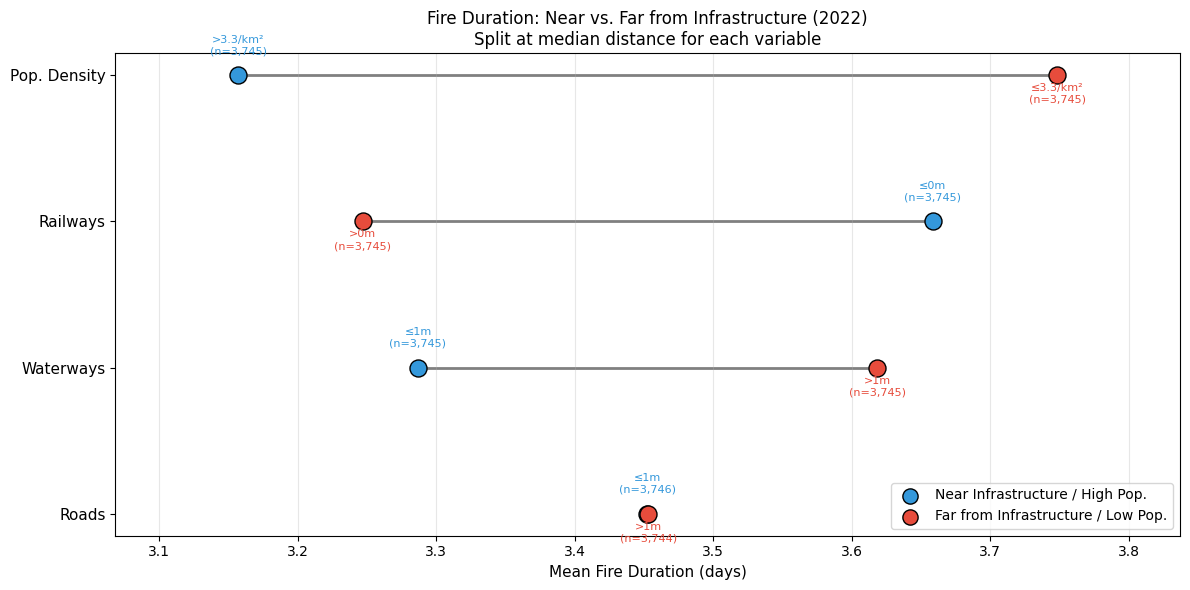

In [182]:
plt.close('all')

comparisons = []

for var, label in [
    ("dist_roads_mean", "Roads"),
    ("dist_water_mean", "Waterways"),
    ("dist_rail_mean", "Railways")
]:
    median_val = df_fires[var].median()
   
    near_data = df_fires[df_fires[var] <= median_val]
    far_data = df_fires[df_fires[var] > median_val]
   
    comparisons.append({
        "variable": label,
        "near": near_data["duration"].mean(),
        "far": far_data["duration"].mean(),
        "near_label": f"≤{median_val:.0f}m",
        "far_label": f">{median_val:.0f}m",
        "near_n": len(near_data),
        "far_n": len(far_data)
    })

# Population density (High vs Low)
pop_median = df_fires["popdens_2022"].median()
high_pop = df_fires[df_fires["popdens_2022"] > pop_median]
low_pop = df_fires[df_fires["popdens_2022"] <= pop_median]

comparisons.append({
    "variable": "Pop. Density",
    "near": high_pop["duration"].mean(),  # "Near" = High for pop
    "far": low_pop["duration"].mean(),    # "Far" = Low for pop
    "near_label": f">{pop_median:.1f}/km²",
    "far_label": f"≤{pop_median:.1f}/km²",
    "near_n": len(high_pop),
    "far_n": len(low_pop)
})

df_dumbbell = pd.DataFrame(comparisons)

fig, ax = plt.subplots(figsize=(12, 6))

y_positions = range(len(df_dumbbell))

for i, row in df_dumbbell.iterrows():
    # Draw connecting line
    ax.plot(
        [row["near"], row["far"]],
        [i, i],
        color="gray",
        linewidth=2,
        zorder=1
    )
   
    # Draw "Near/High" point
    ax.scatter(
        row["near"], i,
        s=150,
        color="#3498db",
        zorder=2,
        edgecolors="black",
        linewidths=1
    )
   
    # Draw "Far/Low" point
    ax.scatter(
        row["far"], i,
        s=150,
        color="#e74c3c",
        zorder=2,
        edgecolors="black",
        linewidths=1
    )
   
    # Add labels with threshold values
    ax.annotate(
        f'{row["near_label"]}\n(n={row["near_n"]:,})',
        (row["near"], i),
        textcoords="offset points",
        xytext=(0, 15),
        ha="center",
        fontsize=8,
        color="#3498db"
    )
    ax.annotate(
        f'{row["far_label"]}\n(n={row["far_n"]:,})',
        (row["far"], i),
        textcoords="offset points",
        xytext=(0, -20),
        ha="center",
        fontsize=8,
        color="#e74c3c"
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(df_dumbbell["variable"], fontsize=11)
ax.set_xlabel("Mean Fire Duration (days)", fontsize=11)
ax.set_title("Fire Duration: Near vs. Far from Infrastructure (2022)\n"
             "Split at median distance for each variable", fontsize=12)
ax.grid(axis="x", alpha=0.3)

# Legend
ax.scatter([], [], s=120, color="#3498db", edgecolors="black",
           label="Near Infrastructure / High Pop.")
ax.scatter([], [], s=120, color="#e74c3c", edgecolors="black",
           label="Far from Infrastructure / Low Pop.")
ax.legend(loc="lower right", fontsize=10)

# Add some padding
x_min = df_dumbbell[["near", "far"]].min().min()
x_max = df_dumbbell[["near", "far"]].max().max()
x_padding = (x_max - x_min) * 0.15
ax.set_xlim(x_min - x_padding, x_max + x_padding)

plt.tight_layout()
plt.show()

In [184]:
# ============================================================
# STATISTICAL SUMMARY
# ============================================================
print("=" * 60)
print("FIRE ANALYSIS SUMMARY - 2022")
print("=" * 60)

print(f"\nTotal fire events: {len(df_fires):,}")
print(f"Mean duration: {df_fires['duration'].mean():.2f} days")
print(f"Median duration: {df_fires['duration'].median():.2f} days")
print(f"Max duration: {df_fires['duration'].max():.0f} days")

print("\n--- Correlation with Duration ---")
for col in ["popdens_2022", "dist_roads_mean", "dist_water_mean", "dist_rail_mean"]:
    corr = df_fires["duration"].corr(df_fires[col])
    print(f"  {col}: r = {corr:.3f}")

print("\n--- Mean Duration by Population Density ---")
print(df_fires.groupby("pop_bin", observed=True)["duration"].mean().round(2))

print("\n--- Mean Duration by Distance to Roads ---")
print(df_fires.groupby("roads_bin", observed=True)["duration"].mean().round(2))

FIRE ANALYSIS SUMMARY - 2022

Total fire events: 7,490
Mean duration: 3.45 days
Median duration: 2.00 days
Max duration: 10 days

--- Correlation with Duration ---
  popdens_2022: r = -0.033
  dist_roads_mean: r = 0.034
  dist_water_mean: r = 0.059
  dist_rail_mean: r = -0.126

--- Mean Duration by Population Density ---
pop_bin
Very Low\n(0-5)       3.77
Low\n(5-20)           2.94
Med-Low\n(20-50)      2.95
Med-High\n(50-200)    2.68
High\n(200-500)       2.58
Very High\n(500+)     2.90
Name: duration, dtype: float64

--- Mean Duration by Distance to Roads ---
roads_bin
0    3.47
1    3.42
2    3.44
3    3.43
4    3.50
Name: duration, dtype: float64


In [332]:
ds_t0 = ds.isel(time=0)
mask_ac9 = ds_t0["AutonomousCommunities"] == 9
painted = xr.where(mask_ac0, 1, 0)
X, Y = xr.broadcast(ds_t0["x"], ds_t0["y"])

In [400]:
region = xr.full_like(X, np.nan, dtype=np.float32)

region = xr.where(mask_ac9  & (X <= 3550000) & (Y<= 2060000), 1, region)
region = xr.where(mask_ac9  & (((X <= ((10*Y + 4250000)/7)) & (Y> 2060000)  & (Y <= 2130000)) | ((X < 3650000) & (Y> 2130000))), 2, region)
region = xr.where(mask_ac9  & ( (X <= 3650000) & (((X > ((10*Y + 4250000)/7)) & (Y> 2060000) & (Y <= 2130000)) | ((X > 3550000) & (Y<= 2060000))) ), 4, region)
region = xr.where(mask_ac9  & (Y <= 2120000) & (X <= (32260000 - 3*Y) / 7) & (X > 3650000), 5, region)
region = xr.where(mask_ac9  & (Y <= 2120000) & (X > (32260000 - 3*Y) / 7) & (X > 3650000), 6, region)
region = xr.where(mask_ac9  & (X > 3650000) & (X <= 3700000) & (Y >2120000), 7, region)
region = xr.where(mask_ac9  & (X > 3700000) & (Y >2120000), 8, region)
region = xr.where(mask_ac9  & (X <= (11 * Y - 13220000) / 3), 3, region)

ds_t0["region"] = region

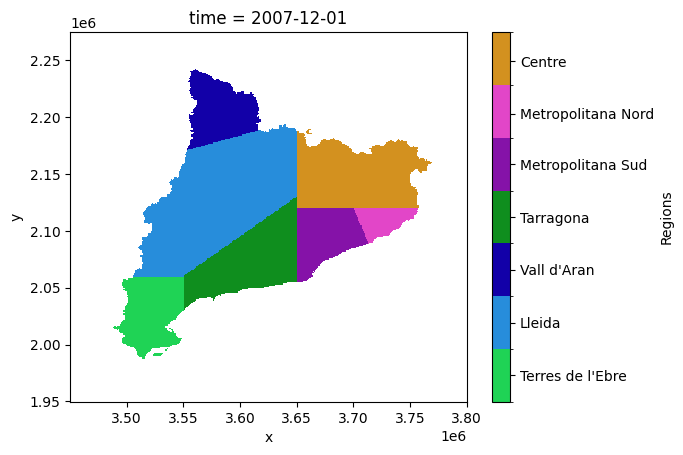

In [401]:
region_labels = {
    1: "Terres de l'Ebre",
    2: "Lleida",
    3: "Vall d'Aran",
    4: "Tarragona",
    5: "Metropolitana Sud",
    6: "Metropolitana Nord",
    7: "Centre",
    8: "Girona",
}

region_colors = [
    "#1fd355",
    "#278ddb",  
    "#1200a8", 
    "#0f8e1e",
    "#8512a8",
    "#e246c8",
    "#cdd31f",
    "#d3911f",
]

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = mcolors.ListedColormap(region_colors)

bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.6, 7.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots()

im = ds_t0["region"].sel(
    x=slice(xmin, xmax),
    y=slice(ymax, ymin),
).plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    add_colorbar=False,
)

cbar = fig.colorbar(
    im,
    ax=ax,
    ticks=list(region_labels.keys()),
)

cbar.ax.set_yticklabels(list(region_labels.values()))
cbar.set_label("Regions")


In [402]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import label

# ============================================================
# STEP 1: Select 2022 data and load to memory
# ============================================================
ds_2022 = ds.sel(time=slice("2022-01-01", "2022-12-31"))

print("Loading data to memory...")

# Fire data
fire_vals = ds_2022["is_fire"].values
fire_vals = np.nan_to_num(fire_vals, nan=0)

# Region data (static - from ds_t0 which you already created)
region_vals = ds_t0["region"]

print(f"  Fire data shape: {fire_vals.shape}")
print(f"  Region data shape: {region_vals.shape}")

Loading data to memory...
  Fire data shape: (365, 920, 1188)
  Region data shape: (920, 1188)


In [403]:
# ============================================================
# STEP 2: Process fire events by region (optimized)
# ============================================================
print("\nProcessing fire events...")

# Find pixels with fires
has_fire = fire_vals.any(axis=0)
fire_pixels = np.argwhere(has_fire)
print(f"  Found {len(fire_pixels)} pixels with fire activity")

# Extract fire events
records = []

for iy, ix in fire_pixels:
    ts = fire_vals[:, iy, ix]
    pixel_region = region_vals[iy, ix]
   
    # Skip if region is NaN (outside the study area)
    if np.isnan(pixel_region):
        continue
   
    # Label connected fire segments
    labels, n_fires = label(ts)
   
    for fire_id in range(1, n_fires + 1):
        fire_indices = np.where(labels == fire_id)[0]
        duration = len(fire_indices)
       
        records.append({
            "region": int(pixel_region),
            "duration": duration,
        })

df_fires = pd.DataFrame(records)
df_fires = df_fires[df_fires["duration"] > 0]
print(f"  Extracted {len(df_fires)} fire events")





Processing fire events...
  Found 7212 pixels with fire activity
  Extracted 160 fire events


In [404]:
# ============================================================
# STEP 3: Aggregate by region
# ============================================================
region_stats = None
region_stats = df_fires.groupby("region").agg(
    fire_count=("duration", "count"),
    mean_duration=("duration", "mean"),
    median_duration=("duration", "median"),
    total_fire_days=("duration", "sum")
).reset_index()

# Region labels and colors (from your code)
region_labels = {
    1: "Regió d'Emergències Terres de l'Ebre",
    2: "Regió d'Emergències Lleida",
    3: "Regió d'Emergències Vall d'Aran",
    4: "Regió d'Emergències Tarragona",
    5: "Regió d'Emergències Metropolitana Sud",
    6: "Regió d'Emergències Metropolitana Nord",
    7: "Regió d'Emergències Centre",
    8: "Regió d'Emergències Girona",
}

region_colors = {
    1: "#1fd355",
    2: "#278ddb",
    3: "#1200a8",
    4: "#0f8e1e",
    5: "#8512a8",
    6: "#e246c8",
    7: "#cdd31f",
    8: "#d3911f",
}

region_stats["region_name"] = region_stats["region"].map(region_labels)
region_stats["color"] = region_stats["region"].map(region_colors)

print("\nFire statistics by region:")
print(region_stats)


Fire statistics by region:
   region  fire_count  mean_duration  median_duration  total_fire_days  \
0       1          12       3.000000              3.0               36   
1       2          82       3.439024              5.0              282   
2       3           9       1.333333              1.0               12   
3       4          42       1.833333              2.0               77   
4       6           3       1.000000              1.0                3   
5       8          12       1.000000              1.0               12   

                              region_name    color  
0    Regió d'Emergències Terres de l'Ebre  #1fd355  
1              Regió d'Emergències Lleida  #278ddb  
2         Regió d'Emergències Vall d'Aran  #1200a8  
3           Regió d'Emergències Tarragona  #0f8e1e  
4  Regió d'Emergències Metropolitana Nord  #e246c8  
5              Regió d'Emergències Girona  #d3911f  


In [405]:

# ============================================================
# STEP 4: Load firefighter data from CSV
# ============================================================
# CSV has columns: region_name, ff_normal, ff_volunteer
ff_data = pd.read_csv("bombers.csv")

print("\nFirefighter data:")
print(ff_data)

# Merge with region stats
region_stats = region_stats.merge(ff_data, on="region", how="outer")

region_stats


Firefighter data:
    Any  region                                   Regió Codi regió  \
0  2022       7              Regió d'Emergències Centre        REC   
1  2022       8              Regió d'Emergències Girona        REG   
2  2022       2              Regió d'Emergències Lleida        REL   
3  2022       6  Regió d'Emergències Metropolitana Nord       REMN   
4  2022       5   Regió d'Emergències Metropolitana Sud       REMS   
5  2022       4           Regió d'Emergències Tarragona        RET   
6  2022       1    Regió d'Emergències Terres de l’Ebre       RETE   
7  2022       3          Regió d'Emergències Val d’Aran       UFVA   

   Funcionaris  Voluntaris  
0           10          10  
1           16          10  
2            9          22  
3           11          11  
4           10           9  
5            8           7  
6            7           5  
7            0           3  


,region,fire_count,mean_duration,median_duration,total_fire_days,region_name,color,Any,Regió,Codi regió,Funcionaris,Voluntaris
0,1,12.0,3.000000,3.0,36.0,Regió d'Emergències Terres de l'Ebre,#1fd355,2022,Regió d'Emergències Terres de l’Ebre,RETE,7,5
1,2,82.0,3.439024,5.0,282.0,Regió d'Emergències Lleida,#278ddb,2022,Regió d'Emergències Lleida,REL,9,22
2,3,9.0,1.333333,1.0,12.0,Regió d'Emergències Vall d'Aran,#1200a8,2022,Regió d'Emergències Val d’Aran,UFVA,0,3
3,4,42.0,1.833333,2.0,77.0,Regió d'Emergències Tarragona,#0f8e1e,2022,Regió d'Emergències Tarragona,RET,8,7
4,5,NaN,NaN,NaN,NaN,NaN,NaN,2022,Regió d'Emergències Metropolitana Sud,REMS,10,9
5,6,3.0,1.000000,1.0,3.0,Regió d'Emergències Metropolitana Nord,#e246c8,2022,Regió d'Emergències Metropolitana Nord,REMN,11,11
6,7,NaN,NaN,NaN,NaN,NaN,NaN,2022,Regió d'Emergències Centre,REC,10,10
7,8,12.0,1.000000,1.0,12.0,Regió d'Emergències Girona,#d3911f,2022,Regió d'Emergències Girona,REG,16,10


In [406]:

# Calculate total firefighters
region_stats["ff_total"] = region_stats["Funcionaris"] + region_stats["Voluntaris"]

# Calculate efficiency metrics
region_stats["ff_per_fire"] = region_stats["ff_total"] / region_stats["fire_count"]
region_stats["fires_per_ff"] = region_stats["fire_count"] / region_stats["ff_total"]


In [407]:
region_stats = region_stats.fillna(0)

region_stats.loc[region_stats.region == 5, 'region_name'] =  "Regió d'Emergències Metropolitana Sud"
region_stats.loc[region_stats.region == 7, 'region_name'] =  "Regió d'Emergències Centre"


print("\nCombined statistics:")
print(region_stats[["region", "region_name", "fire_count", "mean_duration", "ff_total", "ff_per_fire"]])


Combined statistics:
   region                             region_name  fire_count  mean_duration  \
0       1    Regió d'Emergències Terres de l'Ebre        12.0       3.000000   
1       2              Regió d'Emergències Lleida        82.0       3.439024   
2       3         Regió d'Emergències Vall d'Aran         9.0       1.333333   
3       4           Regió d'Emergències Tarragona        42.0       1.833333   
4       5   Regió d'Emergències Metropolitana Sud         0.0       0.000000   
5       6  Regió d'Emergències Metropolitana Nord         3.0       1.000000   
6       7              Regió d'Emergències Centre         0.0       0.000000   
7       8              Regió d'Emergències Girona        12.0       1.000000   

   ff_total  ff_per_fire  
0        12     1.000000  
1        31     0.378049  
2         3     0.333333  
3        15     0.357143  
4        19     0.000000  
5        22     7.333333  
6        20     0.000000  
7        26     2.166667  


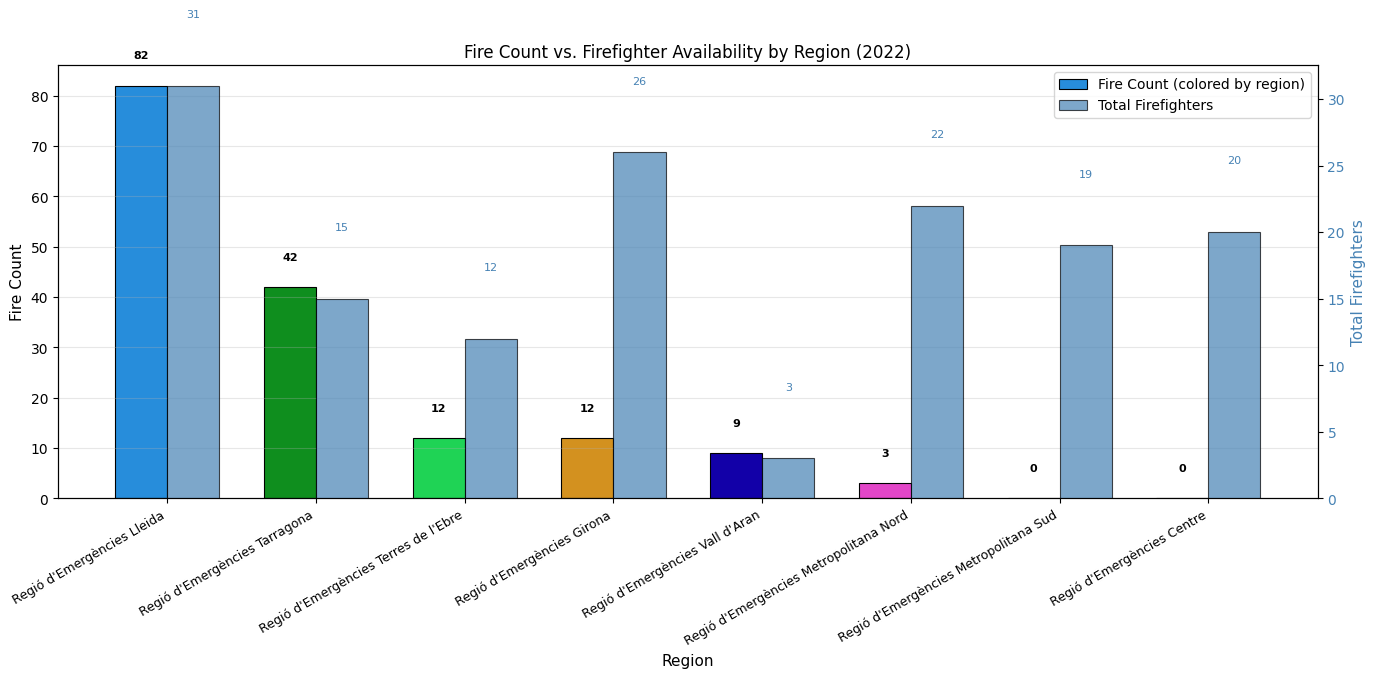

In [408]:
import math
plt.close('all')

fig, ax1 = plt.subplots(figsize=(14, 7))

# Sort by fire count for better visualization
region_stats_sorted = region_stats.sort_values("fire_count", ascending=False)

x = np.arange(len(region_stats_sorted))
width = 0.35

# Bar 1: Fire Count (left y-axis)
bars1 = ax1.bar(
    x - width/2,
    region_stats_sorted["fire_count"],
    width,
    label="Fire Count",
    color=[region_colors[r] for r in region_stats_sorted["region"]],
    edgecolor="black",
    linewidth=0.8
)

ax1.set_xlabel("Region", fontsize=11)
ax1.set_ylabel("Fire Count", fontsize=11, color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Bar 2: Total Firefighters (right y-axis)
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    region_stats_sorted["ff_total"],
    width,
    label="Total Firefighters",
    color="steelblue",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.7
)

ax2.set_ylabel("Total Firefighters", fontsize=11, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(region_stats_sorted["region_name"], rotation=30, ha="right", fontsize=9)

# Add value labels on bars
for bar, val in zip(bars1, region_stats_sorted["fire_count"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{0 if math.isnan(val) else int(val)}", ha="center", va="bottom", fontsize=8, fontweight="bold")

for bar, val in zip(bars2, region_stats_sorted["ff_total"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{0 if math.isnan(val) else int(val)}", ha="center", va="bottom", fontsize=8, color="steelblue")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    [bars1[0], bars2[0]],
    ["Fire Count (colored by region)", "Total Firefighters"],
    loc="upper right"
)

ax1.set_title("Fire Count vs. Firefighter Availability by Region (2022)", fontsize=12)
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


Region 1 (Regió d'Emergències Terres de l'Ebre): centroid at (3521931, 2028027)
Region 2 (Regió d'Emergències Lleida): centroid at (3581438, 2127475)
Region 3 (Regió d'Emergències Vall d'Aran): centroid at (3582426, 2205218)
Region 4 (Regió d'Emergències Tarragona): centroid at (3608659, 2074542)
Region 5 (Regió d'Emergències Metropolitana Sud): centroid at (3675058, 2094419)
Region 6 (Regió d'Emergències Metropolitana Nord): centroid at (3725867, 2108848)
Region 7 (Regió d'Emergències Centre): centroid at (3674635, 2149393)
Region 8 (Regió d'Emergències Girona): centroid at (3729662, 2147618)


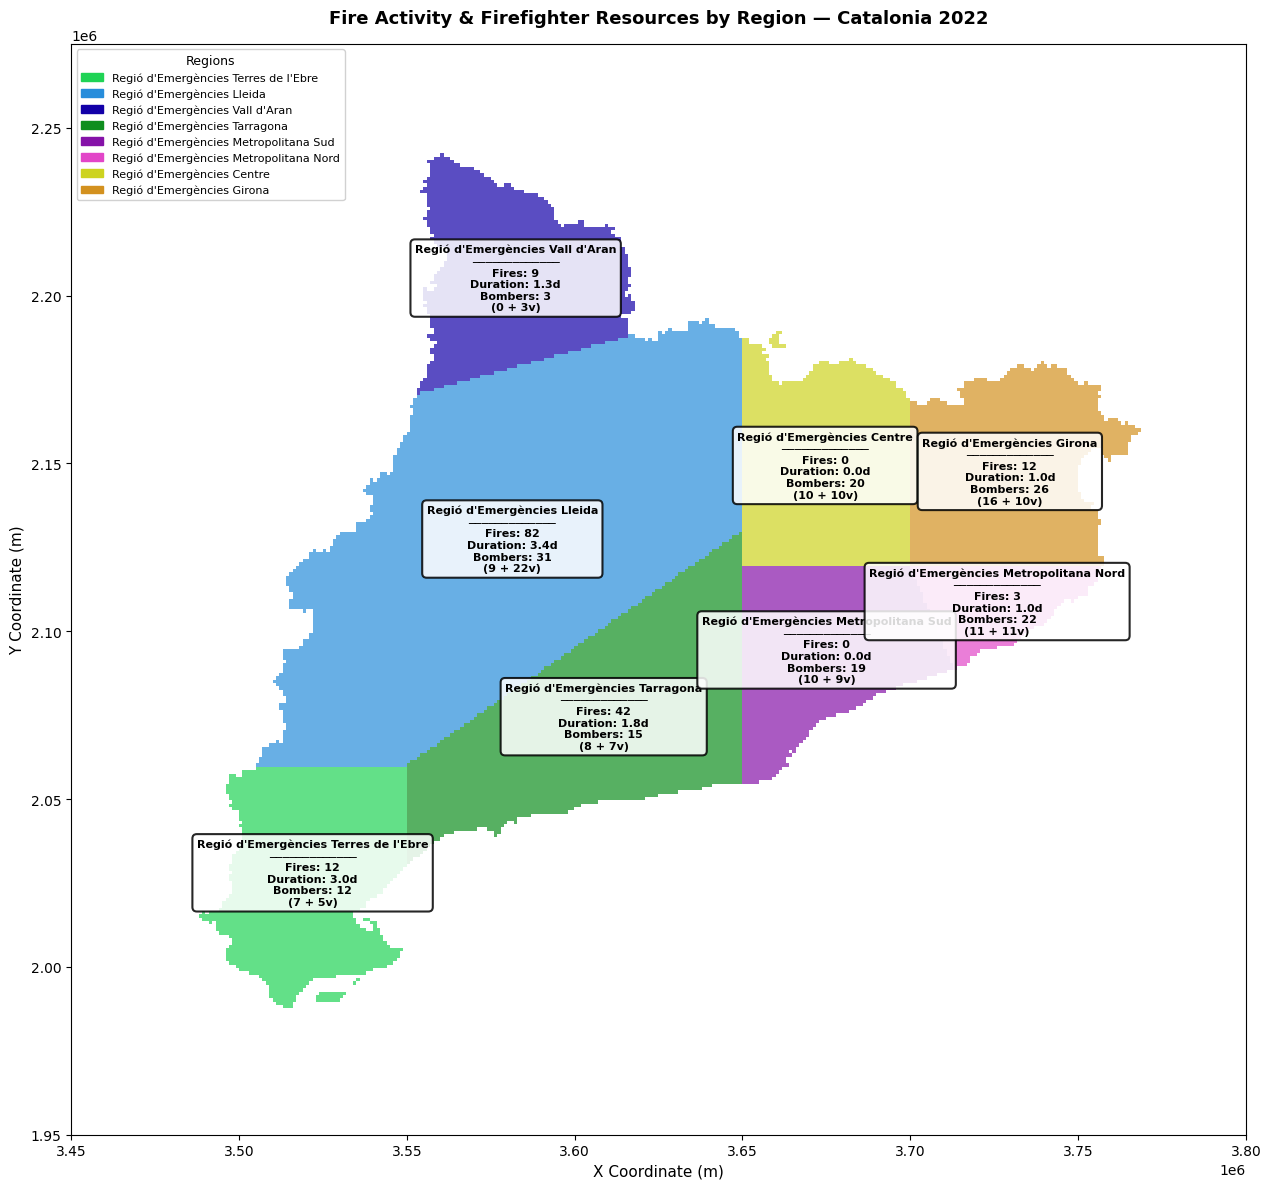

In [409]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

# ============================================================
# STEP 1: Calculate centroids for each region
# ============================================================

# Get x and y coordinates from the dataset
x_coords = ds_t0["x"].values
y_coords = ds_t0["y"].values

# Calculate centroid for each region
centroids = {}

for region_id in region_labels.keys():
    mask = region_vals == region_id
   
    if mask.any():
        # Get indices where this region exists
        y_indices, x_indices = np.where(mask)
       
        # Convert to actual coordinates
        region_x_coords = x_coords[x_indices]
        region_y_coords = y_coords[y_indices]
       
        # Calculate centroid
        centroid_x = region_x_coords.mean()
        centroid_y = region_y_coords.mean()
       
        centroids[region_id] = (centroid_x, centroid_y)
        print(f"Region {region_id} ({region_labels[region_id]}): centroid at ({centroid_x:.0f}, {centroid_y:.0f})")

# ============================================================
# STEP 2: Create the combined map visualization
# ============================================================
plt.close('all')

# FIX: Convert dictionary values to list in correct order (keys 1-8)
region_colors_list = [region_colors[i] for i in sorted(region_colors.keys())]

# Colormap setup - use the LIST, not the dictionary
cmap = mcolors.ListedColormap(region_colors_list)
bounds = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(14, 12))

# Plot the region map
im = ax.imshow(
    region_vals,
    extent=[x_coords.min(), x_coords.max(), y_coords.min(), y_coords.max()],
    origin="upper",
    cmap=cmap,
    norm=norm,
    alpha=0.7
)

# ============================================================
# STEP 3: Add statistics annotations for each region
# ============================================================

for region_id, (cx, cy) in centroids.items():
    # Get statistics for this region
    stats = region_stats[region_stats["region"] == region_id]
   
    if len(stats) == 0:
        continue
   
    row = stats.iloc[0]
   
    fire_count = int(row["fire_count"])
    mean_dur = row["mean_duration"]
    ff_total = int(row["ff_total"])
    ff_normal = int(row["Funcionaris"])
    ff_volunteer = int(row["Voluntaris"])
   
    # Create annotation text
    annotation_text = (
        f"{region_labels[region_id]}\n"
        f"─────────────\n"
        f"Fires: {fire_count:,}\n"
        f"Duration: {mean_dur:.1f}d\n"
        f"Bombers: {ff_total:,}\n"
        f"({ff_normal} + {ff_volunteer}v)"
    )
   
    # Add text box at centroid
    ax.annotate(
        annotation_text,
        (cx, cy),
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor="black",
            alpha=0.85,
            linewidth=1.5
        )
    )

ax.set_xlabel("X Coordinate (m)", fontsize=11)
ax.set_ylabel("Y Coordinate (m)", fontsize=11)
ax.set_title("Fire Activity & Firefighter Resources by Region — Catalonia 2022",
             fontsize=13, fontweight="bold", pad=15)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# FIX: Legend - iterate over actual dictionary keys
legend_patches = [
    mpatches.Patch(color=region_colors[region_id], label=region_labels[region_id])
    for region_id in sorted(region_labels.keys())
]
ax.legend(handles=legend_patches, loc="upper left", title="Regions",
          fontsize=8, title_fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()
